In [21]:
import pandas as pd
import polars as pl
import numpy as np
import xarray as xr
import scipy.stats as stats
import matplotlib.pyplot as plt
import npc_lims
# from npc_sessions import DynamicRoutingSession
from dynamic_routing_analysis import spike_utils
from dynamic_routing_analysis import data_utils
import lazynwb

import os
import pickle
import upath

%load_ext autoreload
%autoreload 2
# %matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [174]:
# session_id='742903_2024-10-22' #good DR
session_id="664851_2023-11-13" #mediocre DR
# session_id="670180_2023-07-27" #templeton

session_info=npc_lims.get_session_info(session_id)
trials=data_utils.load_trials_or_units(session_info, 'trials', version='0.0.272')
units=data_utils.load_trials_or_units(session_info, 'units', version='0.0.272')

664851_2023-11-13 cached trials loaded
664851_2023-11-13 cached units loaded


In [175]:
#filter units

units_filtered = units.query(
    'presence_ratio>=0.7 and \
    isi_violations_ratio<=0.5 and \
    amplitude_cutoff<=0.1 and \
    activity_drift<=0.2 and \
    firing_rate>=0.5 and \
    ~structure.isna() and ~location.isna()'
    ).sort_values(['electrode_group_name', 'peak_channel', 'unit_id'])


In [176]:
#make data arrays

time_before = 1.5
time_after = 0.01
binsize = 1.5
baseline_single_bin_da = spike_utils.make_neuron_time_trials_tensor(units_filtered, trials, time_before, time_after, binsize)

time_before = 1.5
time_after = 0.01
binsize = 0.05
baseline_small_bins_da = spike_utils.make_neuron_time_trials_tensor(units_filtered, trials, time_before, time_after, binsize)


In [177]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X_train_baseline = baseline_single_bin_da.data.reshape(baseline_single_bin_da.data.shape[0], -1).T
y_train_baseline = trials['is_vis_rewarded']
baseline_lda = LinearDiscriminantAnalysis(n_components=1) # Project to 1 dimension
baseline_lda.fit(X_train_baseline, y_train_baseline)


LinearDiscriminantAnalysis(n_components=1)

In [178]:
baseline_small_bins_da.coords

Coordinates:
  * unit_id  (unit_id) object '664851_2023-11-13_A-281' ... '664851_2023-11-1...
  * time     (time) float64 -1.475 -1.425 -1.375 -1.325 ... -0.125 -0.075 -0.025
  * trials   (trials) int64 0 1 2 3 4 5 6 7 ... 516 517 518 519 520 521 522 523

In [179]:
unique_structures=units_filtered['structure'].unique()
print(unique_structures)

['CP' 'SSp' 'out of brain' 'ORBl' 'FRP' 'MOs' 'ILA' 'ACAv' 'ACAd' 'MRN'
 'PAG' 'SCdw' 'SCdg' 'SCiw' 'SCig' 'SCop' 'SCsg' 'SCzo' 'RSPv' 'RSPd'
 'RSPagl' 'NPC' 'V3' 'VISam' 'VPL' 'VPM' 'RT']


In [180]:
#apply model to small-bin baseline per time bin

projections_by_structure={}

for sel_structure in unique_structures:

    structure_mask = units_filtered['structure'] == sel_structure
    structure_units = units_filtered[structure_mask]
    structure_unit_ids = structure_units['unit_id'].values
    
    #select data for these units
    structure_small_bins_da = baseline_small_bins_da.sel(unit_id=structure_unit_ids)
    structure_single_bin_da = baseline_single_bin_da.sel(unit_id=structure_unit_ids)

    #fit model for this structure using single-bin data
    X_structure_single_bin = structure_single_bin_da.data.reshape(structure_single_bin_da.data.shape[0], -1).T
    y_structure_single_bin = trials['is_vis_rewarded']
    structure_lda = LinearDiscriminantAnalysis(n_components=1)
    structure_lda.fit(X_structure_single_bin, y_structure_single_bin)

    #project each time bin separately and store projections
    projections_list = {
        'time':[],
        'projection':[],
    }

    for time_bin in structure_small_bins_da.coords['time'].values:
        temp_single_bin_da = structure_small_bins_da.sel(time=time_bin)
        X_single_bin = temp_single_bin_da.data.reshape(temp_single_bin_da.data.shape[0], -1).T
        structure_single_bin_projection = structure_lda.transform(X_single_bin)
        projections_list['time'].append(time_bin)
        projections_list['projection'].append(structure_single_bin_projection)

    #build new xarray from projections per bin
    projections_da = xr.DataArray(
        data=np.concatenate(projections_list['projection'], axis=1).T, # Concatenate projections along the time dimension
        coords={
            'time': projections_list['time'],
            'trials': structure_small_bins_da.coords['trials'].values
        },
        dims=['time', 'trials']
    )

    projections_by_structure[sel_structure] = projections_da


In [181]:
projections_by_structure.keys()

dict_keys(['CP', 'SSp', 'out of brain', 'ORBl', 'FRP', 'MOs', 'ILA', 'ACAv', 'ACAd', 'MRN', 'PAG', 'SCdw', 'SCdg', 'SCiw', 'SCig', 'SCop', 'SCsg', 'SCzo', 'RSPv', 'RSPd', 'RSPagl', 'NPC', 'V3', 'VISam', 'VPL', 'VPM', 'RT'])

In [275]:
sel_structure_1 = 'MRN'
sel_structure_2 = 'FRP'

projection_1 = projections_by_structure[sel_structure_1]
projection_2 = projections_by_structure[sel_structure_2]

#append nans equal to length of trials to end of each trial to facilitate corss correlation later
nans_to_append = xr.DataArray(
    data=np.full((projection_1.data.shape[0], projection_1.data.shape[1]), np.nan), 
    coords=projection_1.coords,
    dims=projection_1.dims,
)
projection_1 = xr.concat((projection_1, nans_to_append), "time")
projection_2 = xr.concat((projection_2, nans_to_append), "time")

#flatten projections, keep trials together
projection_1_flat = projection_1.data.flatten(order='F')
projection_2_flat = projection_2.data.flatten(order='F')


In [276]:
# projection_1

In [277]:
# fig,ax=plt.subplots()
# scatter = ax.scatter(projection_1_flat, projection_2_flat, c=trial_labels, cmap='bwr', alpha=0.5)
# legend1 = ax.legend(*scatter.legend_elements(), title="Trial Labels")
# ax.add_artist(legend1)

(0.0, 1000.0)

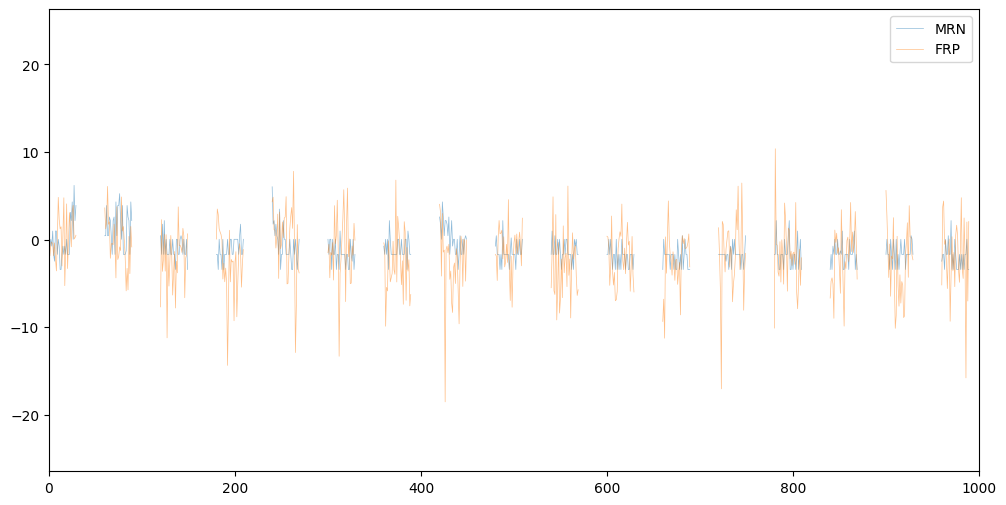

In [278]:
fig,ax=plt.subplots(1,1,figsize=(12,6))
ax.plot(projection_1_flat, label=sel_structure_1, alpha=0.5, linewidth=0.5)
ax.plot(projection_2_flat, label=sel_structure_2, alpha=0.5, linewidth=0.5)
ax.legend()
ax.set_xlim(0,1000)

In [279]:
#try correlating the whole trace but only use valid points, limit number of shifts
sel_structure_1 = 'MRN'
sel_structure_2 = 'FRP'

projection_1 = projections_by_structure[sel_structure_1]
projection_2 = projections_by_structure[sel_structure_2]

#append nans equal to length of trials to end of each trial to facilitate corss correlation later
nans_to_append = xr.DataArray(
    data=np.full((projection_1.data.shape[0], projection_1.data.shape[1]), np.nan), 
    coords=projection_1.coords,
    dims=projection_1.dims,
)
projection_1 = xr.concat((projection_1, nans_to_append), "time")
projection_2 = xr.concat((projection_2, nans_to_append), "time")

#flatten projections, keep trials together
projection_1_flat = projection_1.data.flatten(order='F')
projection_2_flat = projection_2.data.flatten(order='F')

#limit n shifts for cross correlation
n_shifts=13

valid_lags=np.arange(-n_shifts, n_shifts+1)

zero_ind=np.where(valid_lags==0)[0][0]

#do correlation manually
corr = np.full(len(valid_lags),np.nan)

###double check this is right!

for i, lag in enumerate(valid_lags):
    
    nanind_1 = np.isnan(projection_1_flat)
    nanind_2 = np.isnan(projection_2_flat)

    if lag < 0:
        combined_nanind = nanind_1[:len(projection_1_flat)+lag] | nanind_2[-lag:len(projection_1_flat)]
        corr[i] = stats.pearsonr(projection_1_flat[:len(projection_1_flat)+lag][~combined_nanind], projection_2_flat[-lag:len(projection_1_flat)][~combined_nanind])[0]
    elif lag > 0:
        combined_nanind = nanind_1[lag:len(projection_1_flat)] | nanind_2[:len(projection_1_flat)-lag]
        corr[i] = stats.pearsonr(projection_1_flat[lag:len(projection_1_flat)][~combined_nanind], projection_2_flat[:len(projection_1_flat)-lag][~combined_nanind])[0]
    else:
        combined_nanind = nanind_1 | nanind_2
        corr[i] = stats.pearsonr(projection_1_flat[~combined_nanind], projection_2_flat[~combined_nanind])[0]
        

lag_times = valid_lags * 0.05

max_correlation_index = np.argmax(corr)
best_lag = lag_times[max_correlation_index]

In [280]:
lag_times
# best_lag

array([-0.65, -0.6 , -0.55, -0.5 , -0.45, -0.4 , -0.35, -0.3 , -0.25,
       -0.2 , -0.15, -0.1 , -0.05,  0.  ,  0.05,  0.1 ,  0.15,  0.2 ,
        0.25,  0.3 ,  0.35,  0.4 ,  0.45,  0.5 ,  0.55,  0.6 ,  0.65])

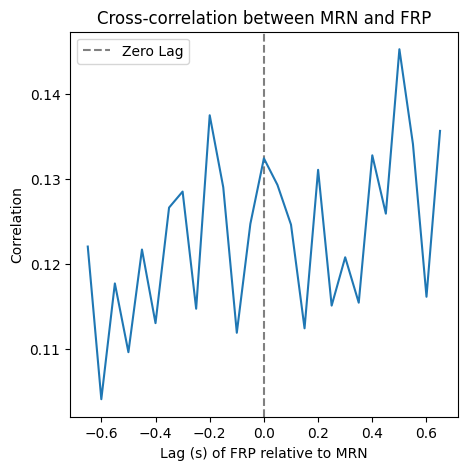

In [281]:
fig,ax = plt.subplots(figsize=(5,5))
ax.axvline(0, color='gray', linestyle='--', label='Zero Lag')
ax.plot(lag_times, corr)
ax.set_xlabel(f"Lag (s) of {sel_structure_2} relative to {sel_structure_1}")
ax.set_ylabel("Correlation")
ax.set_title(f"Cross-correlation between {sel_structure_1} and {sel_structure_2}")
ax.legend()

In [29]:
# baseline_small_bins_da.coords
# baseline_single_bin_da.shape

In [ ]:
# baseline_small_bins_projection.shape
# X_small_bins.shape

(8070, 1442)

In [8]:
#plot projection over time
time_bins = baseline_small_bins_da.coords['time'].values
plt.figure(figsize=(10,6))
for trial_type, color in zip([0, 1], ['blue', 'orange']):
    trial_mask = trials['is_vis_rewarded'] == trial_type
    plt.plot(time_bins, baseline_small_bins_projection[trial_mask].T, color=color, alpha=0.1)
plt.xlabel('Time (s)')
plt.ylabel('LDA Projection')

IndexError: boolean index did not match indexed array along dimension 0; dimension is 8070 but corresponding boolean dimension is 538

<Figure size 1000x600 with 0 Axes>